In [11]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import recall_score, precision_score, f1_score, average_precision_score, confusion_matrix, PrecisionRecallDisplay
import matplotlib.pyplot as plt
import seaborn as sns

In [12]:
df = pd.read_csv('creditcard.csv')

In [13]:
n_estimators_options    = [50, 100, 300, 500]
max_depth_options       = [5, 10, 20, None]
leaf_options            = [10, 15, 20, 25]

In [14]:
y     = df['Class']
df.drop(columns="Class", inplace=True)
X_all = df

X_train, X_test, y_train, y_test = train_test_split(
    X_all, y, test_size=0.3, stratify=y, random_state=42
)
X_eval, X_test, y_eval, y_test = train_test_split(
    X_test, y_test, test_size=0.5, stratify=y_test, random_state=42
)

In [15]:
results = []

for n_estimators in n_estimators_options:
    for max_depth in max_depth_options:
        for min_samples_leaf in leaf_options:
            print(f"Training n_estimators={n_estimators}, max_depth={max_depth}, min_samples_leaf={min_samples_leaf}")
            
            model = RandomForestClassifier(
                n_estimators=n_estimators,
                max_depth=max_depth,
                #class_weight='unbalanced',
                random_state=42,
                min_samples_leaf=min_samples_leaf
            )

            model.fit(X_train, y_train)
            y_pred  = model.predict(X_eval)
            y_proba = model.predict_proba(X_eval)[:, 1]

            results.append({
                'n_estimators': n_estimators,
                'max_depth':    max_depth,
                'min_samples_leaf': min_samples_leaf,
                'recall':       recall_score(y_eval, y_pred),
                'precision':    precision_score(y_eval, y_pred),
                'f1':           f1_score(y_eval, y_pred),
                'pr_auc':       average_precision_score(y_eval, y_proba),
            })

results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))
results_df.to_csv('csv_new/random_forest_balanced_train.csv', index=False)

Training n_estimators=50, max_depth=5, min_samples_leaf=10
Training n_estimators=50, max_depth=5, min_samples_leaf=15
Training n_estimators=50, max_depth=5, min_samples_leaf=20
Training n_estimators=50, max_depth=5, min_samples_leaf=25
Training n_estimators=50, max_depth=10, min_samples_leaf=10
Training n_estimators=50, max_depth=10, min_samples_leaf=15
Training n_estimators=50, max_depth=10, min_samples_leaf=20
Training n_estimators=50, max_depth=10, min_samples_leaf=25
Training n_estimators=50, max_depth=20, min_samples_leaf=10
Training n_estimators=50, max_depth=20, min_samples_leaf=15
Training n_estimators=50, max_depth=20, min_samples_leaf=20
Training n_estimators=50, max_depth=20, min_samples_leaf=25
Training n_estimators=50, max_depth=None, min_samples_leaf=10
Training n_estimators=50, max_depth=None, min_samples_leaf=15
Training n_estimators=50, max_depth=None, min_samples_leaf=20
Training n_estimators=50, max_depth=None, min_samples_leaf=25
Training n_estimators=100, max_depth

In [16]:
new_results = pd.read_csv('csv_new/random_forest_balanced_train.csv')
metrics = ['recall', 'precision', 'f1', 'pr_auc']
for metric in metrics:
    best = new_results.sort_values(metric, ascending=False).iloc[0]
    
    print(f"\n══════════════════════════════════════════════════════")
    print(f"BEST MODEL BY {metric.upper()}")
    print(f"══════════════════════════════════════════════════════")
    print(f"  Recall:       {best['recall']:.4f}")
    print(f"  Precision:    {best['precision']:.4f}")
    print(f"  F1:           {best['f1']:.4f}")
    print(f"  PR-AUC:       {best['pr_auc']:.4f}")
    print(f"  n_estimators: {best['n_estimators']}")
    print(f"  min_samples_leaf: {best['min_samples_leaf']}")
    print(f"  max_depth:    {best['max_depth']}")


══════════════════════════════════════════════════════
BEST MODEL BY RECALL
══════════════════════════════════════════════════════
  Recall:       0.7297
  Precision:    0.8571
  F1:           0.7883
  PR-AUC:       0.7997
  n_estimators: 50.0
  min_samples_leaf: 10.0
  max_depth:    20.0

══════════════════════════════════════════════════════
BEST MODEL BY PRECISION
══════════════════════════════════════════════════════
  Recall:       0.7162
  Precision:    0.8983
  F1:           0.7970
  PR-AUC:       0.7852
  n_estimators: 50.0
  min_samples_leaf: 15.0
  max_depth:    20.0

══════════════════════════════════════════════════════
BEST MODEL BY F1
══════════════════════════════════════════════════════
  Recall:       0.7162
  Precision:    0.8983
  F1:           0.7970
  PR-AUC:       0.7852
  n_estimators: 50.0
  min_samples_leaf: 15.0
  max_depth:    20.0

══════════════════════════════════════════════════════
BEST MODEL BY PR_AUC
═══════════════════════════════════════════════════

  Recall:       0.7838
  Precision:    0.8529
  F1:           0.8169
  PR-AUC:       0.8181
  n_estimators: 50.0
  max_depth:    20.0
  Features used: 10.0


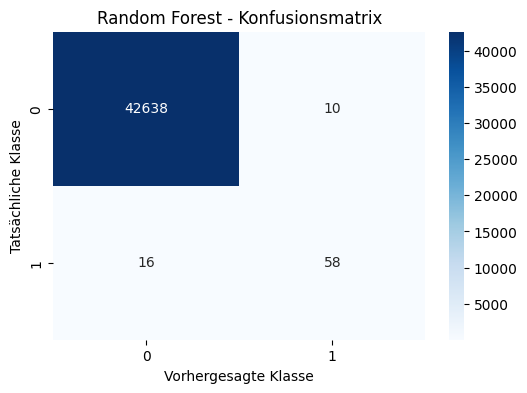

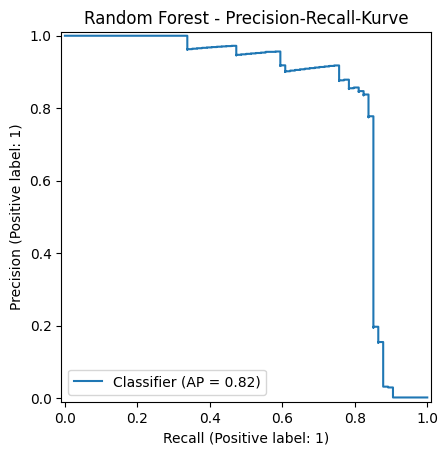

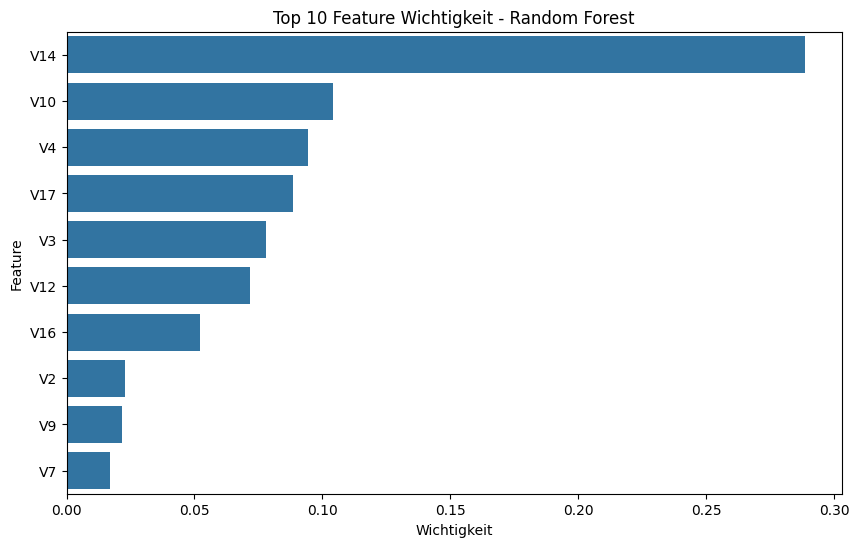

  Recall:       0.7838
  Precision:    0.8529
  F1:           0.8169
  PR-AUC:       0.8181
  n_estimators: 50.0
  max_depth:    20.0
  Features used: 10.0


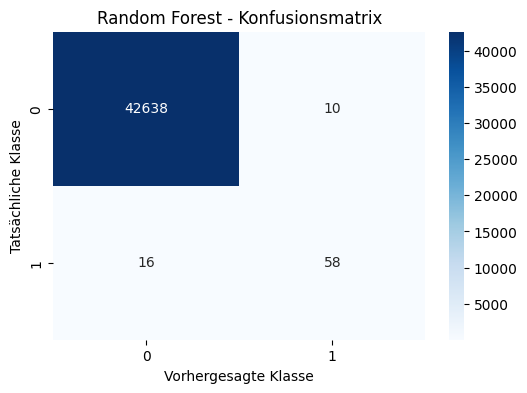

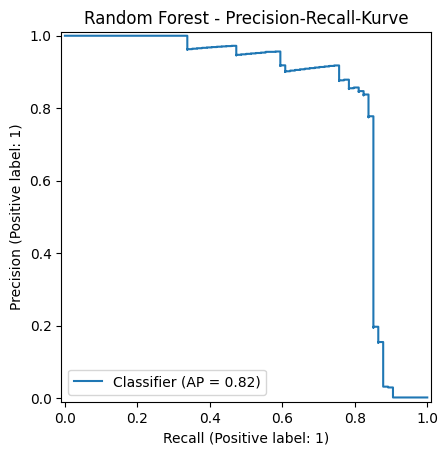

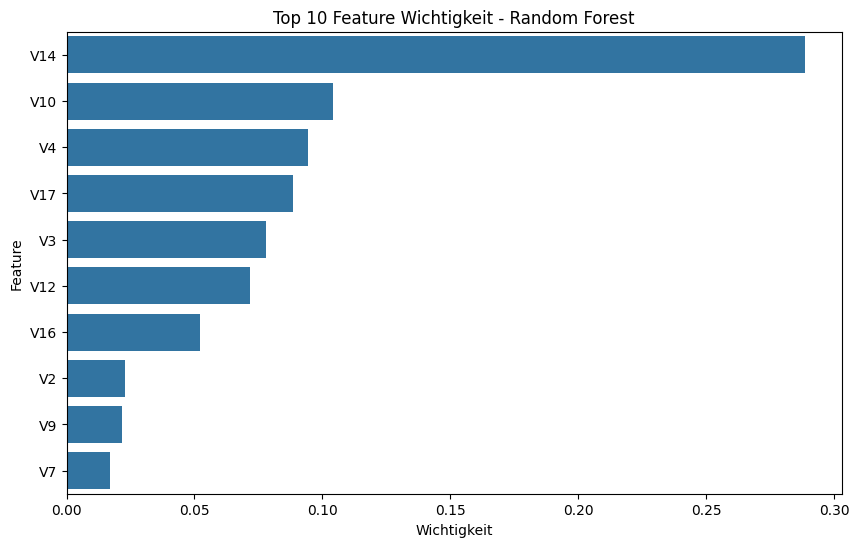

 n_estimators  max_depth  min_samples_leaf   recall  precision       f1   pr_auc
         50.0       20.0              10.0 0.783784   0.852941 0.816901 0.818098
         50.0       20.0              10.0 0.783784   0.852941 0.816901 0.818098


In [17]:
results = []
def evaluate_model(n_estimators, max_depth, min_samples_leaf):
    model = RandomForestClassifier(
        n_estimators=int(n_estimators),
        max_depth=int(max_depth) if pd.notna(max_depth) else None,
        class_weight='balanced',
        random_state=42,
        min_samples_leaf=int(min_samples_leaf)
    )

    model.fit(X_train, y_train)
    y_pred  = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    results.append({
        'n_estimators': n_estimators,
        'max_depth':    max_depth,
        'min_samples_leaf': min_samples_leaf,
        'recall':       recall_score(y_test, y_pred),
        'precision':    precision_score(y_test, y_pred),
        'f1':           f1_score(y_test, y_pred),
        'pr_auc':       average_precision_score(y_test, y_proba),
    })

    print(f"  Recall:       {recall_score(y_test, y_pred):.4f}")
    print(f"  Precision:    {precision_score(y_test, y_pred):.4f}")
    print(f"  F1:           {f1_score(y_test, y_pred):.4f}")
    print(f"  PR-AUC:       {average_precision_score(y_test, y_proba):.4f}")
    print(f"  n_estimators: {n_estimators}")
    print(f"  max_depth:    {max_depth}")
    print(f"  Features used: {min_samples_leaf}")

    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(6,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title("Random Forest - Konfusionsmatrix")
    plt.ylabel('Tatsächliche Klasse')
    plt.xlabel('Vorhergesagte Klasse')
    plt.show()

    PrecisionRecallDisplay.from_predictions(y_test, y_proba)
    plt.title("Random Forest - Precision-Recall-Kurve")
    plt.show()

    # Angenommen, dein Modell heißt 'rf_model'
    importances = model.feature_importances_
    feature_names = X_train.columns

    # DataFrame erstellen und sortieren
    rf_imp_df = pd.DataFrame({'Feature': feature_names, 'Wichtigkeit': importances})
    rf_imp_df = rf_imp_df.sort_values(by='Wichtigkeit', ascending=False)

    # Die Top 10 plotten
    plt.figure(figsize=(10, 6))
    sns.barplot(x='Wichtigkeit', y='Feature', data=rf_imp_df.head(10))
    plt.title('Top 10 Feature Wichtigkeit - Random Forest')
    plt.show()

train_rf = pd.read_csv('csv_new/random_forest_balanced_train.csv')
metrics = ['recall', 'pr_auc']
for metric in metrics:
    best = train_rf.sort_values(metric, ascending=False).iloc[0]
    evaluate_model(best['n_estimators'], best['max_depth'], best['min_samples_leaf'])

results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))
results_df.to_csv('csv_new/random_forest_balanced_test.csv', index=False)